   rentals     temp_c  humidity   wind_kph  is_holiday  season
0      657   7.783223  0.225520  18.057709           0  winter
1      632  16.691937  0.533523  15.975831           0  spring
2      546  17.044212  0.879505  13.235575           1  spring
3      650  18.460255  0.623327  18.159102           1  autumn
4      730  19.841524  0.244849   0.500000           1  summer


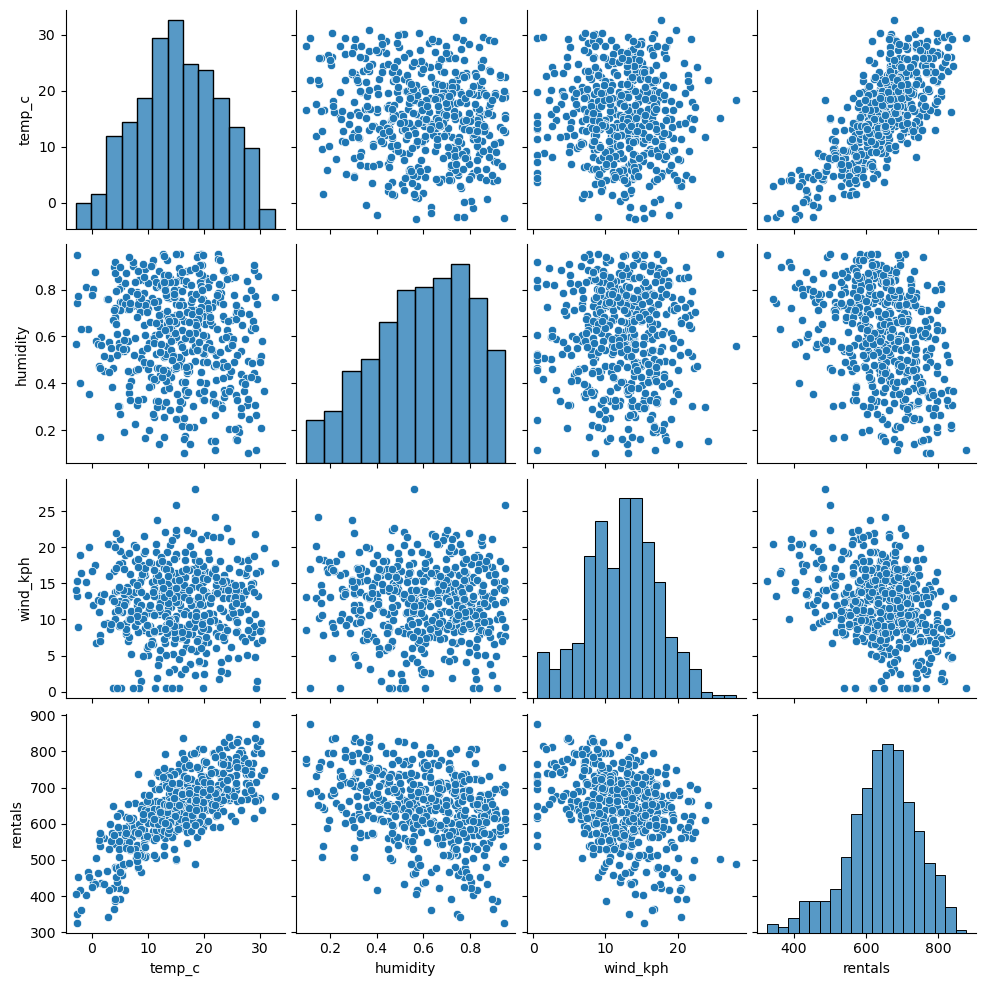

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 23 seconds.


Linear Summary:
          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha    0.000  0.023    -0.047      0.044        0.0      0.0    9943.0   
beta[0]  0.709  0.023     0.664      0.756        0.0      0.0   10477.0   
beta[1] -0.255  0.023    -0.301     -0.211        0.0      0.0    9578.0   
beta[2] -0.332  0.023    -0.380     -0.290        0.0      0.0    9675.0   
sigma    0.516  0.017     0.484      0.549        0.0      0.0    9595.0   

         ess_tail  r_hat  
alpha      5856.0    1.0  
beta[0]    6341.0    1.0  
beta[1]    6238.0    1.0  
beta[2]    5549.0    1.0  
sigma      6107.0    1.0  

Polynomial Summary:
          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha    0.170  0.028     0.118      0.226        0.0      0.0    8682.0   
beta[0]  0.695  0.022     0.653      0.737        0.0      0.0   10183.0   
beta[1] -0.171  0.018    -0.206     -0.136        0.0      0.0    8631.0   
beta[2] -0.265  0.021    -0.308     -0.2

Sampling: [y]


Output()

        rank   elpd_waic    p_waic  elpd_diff        weight         se  \
Poly       0 -340.889796  5.611705   0.000000  1.000000e+00  15.591236   
Linear     1 -380.866891  5.075098  39.977094  4.660994e-12  16.356013   

             dse  warning scale  
Poly    0.000000    False   log  
Linear  7.788119    False   log  


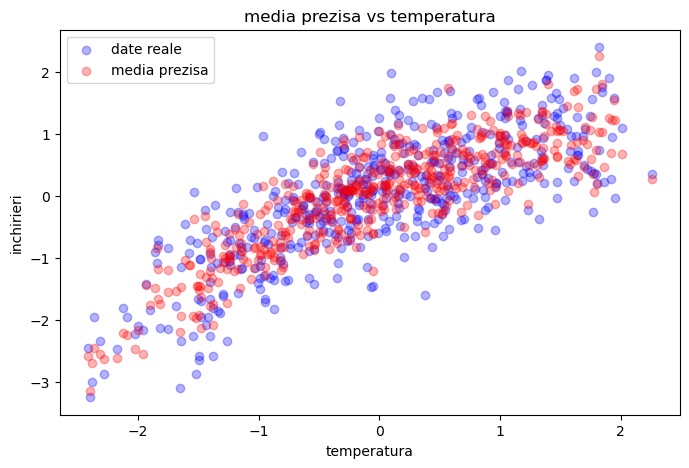

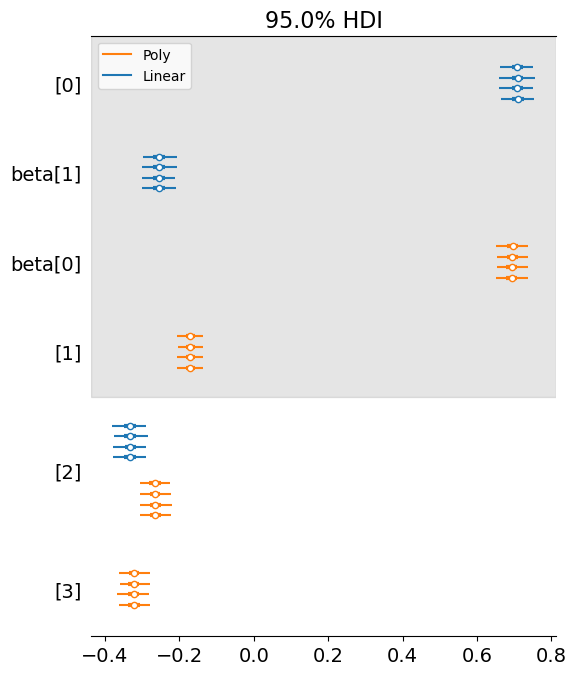

Initializing NUTS using jitter+adapt_diag...


High demand threshold (75th percentile): 708.0


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.



Logistic Model Summary (95% HDI):
          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
alpha   -1.895  0.181    -2.253     -1.543      0.003    0.002    4615.0   
beta[0]  1.643  0.183     1.328      2.038      0.003    0.002    5030.0   
beta[1] -0.919  0.143    -1.200     -0.638      0.002    0.001    5756.0   
beta[2] -1.161  0.159    -1.471     -0.854      0.002    0.002    4847.0   

         ess_tail  r_hat  
alpha      4903.0    1.0  
beta[0]    5647.0    1.0  
beta[1]    5689.0    1.0  
beta[2]    5380.0    1.0  


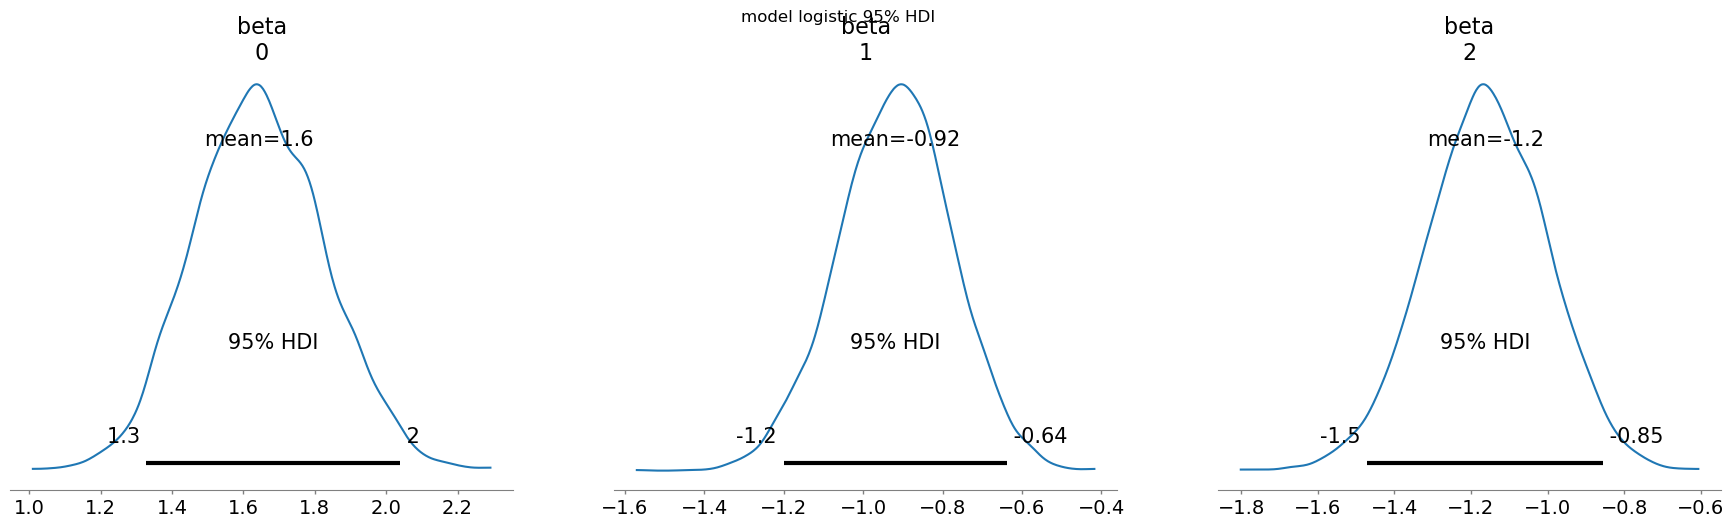

In [14]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

#1
data = pd.read_csv('bike_daily.csv')
print(data.head())

sns.pairplot(data[['temp_c', 'humidity', 'wind_kph', 'rentals']])
plt.show() 

#din grafice observam ca atunci cand temp_c este mai mare atunci si rentals
#este mai mare.
#deoarece graficul este curbat la temperaturi mai mari ar avea sens sa utilizam
#un model cu temp_c2


#2
#a
cols_to_norm = ['temp_c', 'humidity', 'wind_kph']
df_std = data.copy()
for col in cols_to_norm:
    df_std[col] = (data[col] - data[col].mean()) / data[col].std()
df_std['rentals_z'] = (data['rentals'] - data['rentals'].mean()) / data['rentals'].std()

#b
with pm.Model() as lin_mod:
    a = pm.Normal('alpha', 0, 1)
    b = pm.Normal('beta', 0, 1, shape=3)
    eps = pm.Exponential('sigma', 1)

    mu = a + b[0]*df_std['temp_c'] + b[1]*df_std['humidity'] + b[2]*df_std['wind_kph']
    y = pm.Normal('y', mu=mu, sigma=eps, observed=df_std['rentals_z'])
    
    trace_lin = pm.sample(2000, tune=1000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

#c
df_std['temp_c2'] = df_std['temp_c']**2

with pm.Model() as poly_mod:
    a = pm.Normal('alpha', 0, 1)
    b = pm.Normal('beta', 0, 1, shape=4)
    eps = pm.Exponential('sigma', 1)
    
    mu = a + b[0]*df_std['temp_c'] + b[1]*df_std['temp_c2'] + b[2]*df_std['humidity'] + b[3]*df_std['wind_kph']
    y = pm.Normal('y', mu=mu, sigma=eps, observed=df_std['rentals_z'])
    
    trace_poly = pm.sample(2000, tune=1000, target_accept=0.9, idata_kwargs={"log_likelihood": True})

#3
print("Linear Summary:")
print(az.summary(trace_lin, hdi_prob=0.95))

print("\nPolynomial Summary:")
print(az.summary(trace_poly, hdi_prob=0.95))

#ambele modele arata ca temperatura influenteaza cel mai mult

#4
#a
comparison = az.compare({'Linear': trace_lin, 'Poly': trace_poly}, ic="waic")
print(comparison)

#modelul polinomial are scorul mai mic -> este mai bun
#WAIC spune cat de bine va prezice modelul datele moi

#b
with poly_mod:
    ppc = pm.sample_posterior_predictive(trace_poly)
    
    y_pred_mean = ppc.posterior_predictive['y'].mean(dim=['chain', 'draw'])
    
    plt.figure(figsize=(8, 5))
    plt.scatter(df_std['temp_c'], df_std['rentals_z'], alpha=0.3, label='date reale', color='blue')
    plt.scatter(df_std['temp_c'], y_pred_mean, alpha=0.3, label='media prezisa', color='red')
    
    plt.xlabel('temperatura')
    plt.ylabel('inchirieri')
    plt.title('media prezisa vs temperatura')
    plt.legend()
    plt.show()

az.plot_forest([trace_lin, trace_poly], 
               model_names=['Linear', 'Poly'], 
               var_names=['beta'], 
               hdi_prob=0.95)
plt.show()

#5
Q = data['rentals'].quantile(0.75)
data['high_demand'] = (data['rentals'] >= Q).astype(int)
print(f"High demand threshold (75th percentile): {Q}")

#6
with pm.Model() as logit_mod:
    a = pm.Normal('alpha', 0, 1)
    b = pm.Normal('beta', 0, 1, shape=3)
    
    p = pm.math.invlogit(a + b[0]*df_std['temp_c'] + b[1]*df_std['humidity'] + b[2]*df_std['wind_kph'])
    
    out = pm.Bernoulli('out', p=p, observed=data['high_demand'])
    trace_logit = pm.sample(2000, tune=1000, target_accept=0.9)

#nu am pastrat temp_c2 deoarece ar fi fost mai dificil sa calculez predictiile si astfel este mai usor de interpretat


#7
final_summary = az.summary(trace_logit, hdi_prob=0.95)
print("\nLogistic Model Summary (95% HDI):")
print(final_summary)

az.plot_posterior(trace_logit, var_names=['beta'], hdi_prob=0.95)
plt.suptitle("model logistic 95% HDI")
plt.show()

#temperatura influenteaza cel mai mult rezultatele finale
